In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [2]:
df = df.drop(columns=["Unnamed: 0", "id"])

X = df.drop(columns=["satisfaction"])
y = df["satisfaction"]

In [3]:
y = y.map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 10, stratify = y)

In [5]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X_train.select_dtypes(exclude=["number"]).columns

print(categorical_cols)

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class'], dtype='str')


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [7]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [8]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

Baseline - Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

lg = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=10))
])

In [10]:
lg.fit(X_train, y_train);

In [11]:
pred_lg = lg.predict(X_valid)

In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(y_valid, pred_lg)
f1 = f1_score(y_valid, pred_lg)
confusion = confusion_matrix(y_valid, pred_lg)
precision = precision_score(y_valid, pred_lg)
recall = recall_score(y_valid, pred_lg)

print(confusion)
print("Accuracy:", accuracy, "F1:", f1)
print("Precision:", precision, "Recall:", recall)

[[10670  1106]
 [ 1472  7533]]
Accuracy: 0.8759443722631249 F1: 0.8538880072545908
Precision: 0.8719759231392522 Recall: 0.8365352581898945


모델링 및 모델 비교

Decision Tree

In [13]:
tree_numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

In [14]:
tree_preprocessor = ColumnTransformer([
    ("num", tree_numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [15]:
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=10))
])

In [16]:
dt.fit(X_train, y_train);

In [17]:
# 과적합 확인
train_pred_dt = dt.predict(X_train)
valid_pred_dt = dt.predict(X_valid)

print("Train Accuracy:", accuracy_score(y_train, train_pred_dt))
print("Valid Accuracy:", accuracy_score(y_valid, valid_pred_dt))

print("Train F1:", f1_score(y_train, train_pred_dt))
print("Valid F1:", f1_score(y_valid, valid_pred_dt))

Train Accuracy: 1.0
Valid Accuracy: 0.9454309224772629
Train F1: 1.0
Valid F1: 0.9371605896043445


In [18]:
print(confusion_matrix(y_valid, valid_pred_dt))
print("Precision:", precision_score(y_valid, valid_pred_dt))
print("Recall:", recall_score(y_valid, valid_pred_dt))
print("F1:", f1_score(y_valid, valid_pred_dt))

[[11191   585]
 [  549  8456]]
Precision: 0.9352947682778454
Recall: 0.9390338700721821
F1: 0.9371605896043445


Decision Tree가 Logistic Regression보다 높은 검증 성능을 보였지만, Train 성능이 100%여서 과적합 가능성이 있음

In [19]:
depth_results = []

for depth in [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]:

    dt_depth = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(max_depth=depth, random_state=10))
    ])

    dt_depth.fit(X_train, y_train)

    train_pred = dt_depth.predict(X_train)
    valid_pred = dt_depth.predict(X_valid)

    train_accuracy = accuracy_score(y_train, train_pred)
    valid_accuracy = accuracy_score(y_valid, valid_pred)
    valid_f1 = f1_score(y_valid, valid_pred)

    depth_results.append([
        depth,
        train_accuracy,
        valid_accuracy,
        valid_f1
    ])

In [20]:
depth_df = pd.DataFrame(
    depth_results,
    columns=["max_depth", "train_accuracy", "valid_accuracy", "valid_f1"]
)

depth_df

,max_depth,train_accuracy,valid_accuracy,valid_f1
0,2,0.859197,0.865262,0.840692
1,3,0.883390,0.889563,0.877423
2,4,0.887949,0.891680,0.865185
3,5,0.904395,0.908330,0.892767
4,6,0.919830,0.920889,0.909938
5,7,0.930765,0.931380,0.918802
6,8,0.936311,0.936047,0.924347
7,10,0.948811,0.945287,0.935526
8,12,0.960035,0.949714,0.940702
9,15,0.972174,0.950724,0.942381


In [21]:
from sklearn.model_selection import GridSearchCV

dt_grid_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=10))
])

param_grid = {
    "classifier__max_depth": [8, 10, 12, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=dt_grid_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
)

In [22]:
grid_search.fit(X_train, y_train);

In [23]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}
Best CV F1: 0.9430240060889595


In [24]:
best_dt = grid_search.best_estimator_
best_dt_pred = best_dt.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, best_dt_pred))
print("Precision:", precision_score(y_valid, best_dt_pred))
print("Recall:", recall_score(y_valid, best_dt_pred))
print("F1-score:", f1_score(y_valid, best_dt_pred))
print(confusion_matrix(y_valid, best_dt_pred))

Accuracy: 0.9521678456282181
Precision: 0.9578237512858613
Recall: 0.9305941143808995
F1-score: 0.9440126168750704
[[11407   369]
 [  625  8380]]


### Decision Tree 결과

- 기본 Decision Tree는 Logistic Regression보다 높은 검증 성능을 보임
- 하지만 제한 없는 Decision Tree는 Train 성능이 매우 높아 과적합 가능성이 확인
- max_depth를 조절하면서 적절한 복잡도가 필요함을 확인
- GridSearchCV를 이용하여 max_depth, min_samples_split, min_samples_leaf를 조정
- 이후 단일 트리보다 안정적인 성능을 기대할 수 있는 Random Forest와 비교

RandomForest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=10))
])

rf.fit(X_train, y_train);

In [26]:
train_pred_rf = rf.predict(X_train)
valid_pred_rf = rf.predict(X_valid)

print("Train Accuracy:", accuracy_score(y_train, train_pred_rf))
print("Valid Accuracy:", accuracy_score(y_valid, valid_pred_rf))

print("Valid Precision:", precision_score(y_valid, valid_pred_rf))
print("Valid Recall:", recall_score(y_valid, valid_pred_rf))
print("Valid F1:", f1_score(y_valid, valid_pred_rf))

print(confusion_matrix(y_valid, valid_pred_rf))

Train Accuracy: 0.9999879696353596
Valid Accuracy: 0.9621769885953515
Valid Precision: 0.9730631978818924
Valid Recall: 0.9387007218212104
Valid F1: 0.9555731404024418
[[11542   234]
 [  552  8453]]


### Random Forest 결과

- Validation Accuracy: 0.9622
- Precision: 0.9731
- Recall: 0.9387
- F1-score: 0.9556
- 기본 Decision Tree보다 Validation 성능이 향상
- 여러 Decision Tree를 결합함으로써 일반화 성능이 개선된 것으로 볼 수 있음
- 다만 Train Accuracy가 거의 1.0이므로 과적합 가능성은 여전히 존재

Gradient Boosting

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=10))
])

gb.fit(X_train, y_train);

In [28]:
train_pred_gb = gb.predict(X_train)
valid_pred_gb = gb.predict(X_valid)

print("Train Accuracy:", accuracy_score(y_train, train_pred_gb))
print("Valid Accuracy:", accuracy_score(y_valid, valid_pred_gb))

print("Valid Precision:", precision_score(y_valid, valid_pred_gb))
print("Valid Recall:", recall_score(y_valid, valid_pred_gb))
print("Valid F1:", f1_score(y_valid, valid_pred_gb))

print(confusion_matrix(y_valid, valid_pred_gb))

Train Accuracy: 0.9425189177483969
Valid Accuracy: 0.9426399114575814
Valid Precision: 0.9468145945327691
Valid Recall: 0.9192670738478623
Valid F1: 0.9328375028172189
[[11311   465]
 [  727  8278]]


### Gradient Boosting 결과

- Validation Accuracy: 0.9426
- Precision: 0.9468
- Recall: 0.9193
- F1-score: 0.9328
- Train과 Validation 성능이 거의 동일하여 과적합은 크지 않았음
- 하지만 기본 Random Forest보다 Accuracy와 F1-score가 낮게 나타남

XGBoost

In [29]:
from xgboost import XGBClassifier

xgb = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(random_state=10, eval_metric="logloss"))
])

xgb.fit(X_train, y_train);

In [30]:
train_pred_xgb = xgb.predict(X_train)
valid_pred_xgb = xgb.predict(X_valid)

print("Train Accuracy:", accuracy_score(y_train, train_pred_xgb))
print("Valid Accuracy:", accuracy_score(y_valid, valid_pred_xgb))

print("Valid Precision:", precision_score(y_valid, valid_pred_xgb))
print("Valid Recall:", recall_score(y_valid, valid_pred_xgb))
print("Valid F1:", f1_score(y_valid, valid_pred_xgb))

print(confusion_matrix(y_valid, valid_pred_xgb))

Train Accuracy: 0.976913730255164
Valid Accuracy: 0.9626581973918483
Valid Precision: 0.9721170395869191
Valid Recall: 0.9408106607440311
Valid F1: 0.9562076749435666
[[11533   243]
 [  533  8472]]


### XGBoost 결과

- Validation Accuracy: 0.9627
- Precision: 0.9721
- Recall: 0.9408
- F1-score: 0.9562
- 기본 모델 중 가장 높은 Accuracy와 F1-score를 기록
- Random Forest와 성능 차이는 매우 작지만, Train과 Validation 성능 차이는 XGBoost가 더 작았음
- 따라서 Random Forest와 XGBoost를 주요 후보 모델로 선정하여 추가 검증 및 튜닝을 진행

Cross Validation

In [31]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="f1")

print("Random Forest F1:", rf_cv)
print("Random Forest Mean F1:", rf_cv.mean())

Random Forest F1: [0.95787171 0.95429256 0.95274423 0.9569081  0.95654624]
Random Forest Mean F1: 0.955672566059803


In [32]:
xgb_cv = cross_val_score(xgb, X_train, y_train, cv=5, scoring="f1")

print("XGBoost F1:", xgb_cv)
print("XGBoost Mean F1:", xgb_cv.mean())

XGBoost F1: [0.95712777 0.95609344 0.9531316  0.95658915 0.95827176]
XGBoost Mean F1: 0.9562427440275814


### Cross Validation 결과

- Random Forest 평균 F1-score: 0.9557
- XGBoost 평균 F1-score: 0.9562
- 두 모델 모두 Fold별 성능 편차가 작아 비교적 안정적인 성능을 보임
- 평균 F1-score 차이는 매우 작지만 XGBoost가 소폭 높은 성능을 보임
- 따라서 Random Forest와 XGBoost를 최종 후보로 두고 하이퍼파라미터 튜닝 진행

In [34]:
from sklearn.model_selection import RandomizedSearchCV

rf_param = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 15, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=10,
)

rf_random.fit(X_train, y_train);

In [35]:
print("Best Parameters:", rf_random.best_params_)
print("Best CV F1:", rf_random.best_score_)

Best Parameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': None}
Best CV F1: 0.9564981819351948


In [36]:
best_rf = rf_random.best_estimator_
best_rf_pred = best_rf.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, best_rf_pred))
print("Precision:", precision_score(y_valid, best_rf_pred))
print("Recall:", recall_score(y_valid, best_rf_pred))
print("F1:", f1_score(y_valid, best_rf_pred))

print(confusion_matrix(y_valid, best_rf_pred))

Accuracy: 0.9623694721139503
Precision: 0.9729667548602323
Recall: 0.9392559689061633
F1: 0.9558142162956266
[[11541   235]
 [  547  8458]]


### Random Forest 튜닝 결과

- 기본 F1-score: 0.9556
- 튜닝 후 F1-score: 0.9558
- 하이퍼파라미터 튜닝 후 성능이 소폭 향상되었으나 차이는 크지 않음
- 기본 Random Forest 자체가 이미 높은 성능을 보이고 있음을 확인

In [37]:
xgb_param = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [3, 5, 7, 9],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=10,
)

xgb_random.fit(X_train, y_train);

In [38]:
print("Best Parameters:", xgb_random.best_params_)
print("Best CV F1:", xgb_random.best_score_)

Best Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
Best CV F1: 0.9577464129618681


In [39]:
best_xgb = xgb_random.best_estimator_
best_xgb_pred = best_xgb.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, best_xgb_pred))
print("Precision:", precision_score(y_valid, best_xgb_pred))
print("Recall:", recall_score(y_valid, best_xgb_pred))
print("F1:", f1_score(y_valid, best_xgb_pred))

print(confusion_matrix(y_valid, best_xgb_pred))

Accuracy: 0.9641499446609884
Precision: 0.9756968440451509
Recall: 0.9406996113270405
F1: 0.9578786679482105
[[11565   211]
 [  534  8471]]


### XGBoost 튜닝 결과

- Best CV F1-score: 0.9578
- Validation Accuracy: 0.9642
- Precision: 0.9756
- Recall: 0.9410
- F1-score: 0.9580
- 기본 XGBoost 및 Random Forest보다 가장 높은 Validation 성능을 보임
- Cross Validation에서도 성능이 소폭 향상되어 튜닝 효과를 확인
- 따라서 튜닝된 XGBoost를 최종 모델 후보로 선정

## 최종 모델 선정

- Random Forest와 XGBoost가 기본 모델 중 가장 높은 성능을 보임
- 5-Fold Cross Validation에서도 두 모델 모두 안정적인 F1-score를 보임
- 하이퍼파라미터 튜닝 결과 XGBoost가 가장 높은 Validation 성능 기록
- 최종 후보 모델로 Tuned XGBoost를 선정

Tuned XGBoost
- Validation Accuracy: 0.9642
- Precision: 0.9756
- Recall: 0.9410
- F1-score: 0.9580
- CV F1-score: 0.9578

In [40]:
test_df = pd.read_csv("test.csv")

print(test_df.shape)
test_df.head()

(25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [41]:
test_df = test_df.drop(columns=["Unnamed: 0", "id"])

X_test = test_df.drop(columns=["satisfaction"])

y_test = test_df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

In [42]:
final_xgb = xgb_random.best_estimator_

final_xgb.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [43]:
test_pred = final_xgb.predict(X_test)

In [44]:
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test Precision:", precision_score(y_test, test_pred))
print("Test Recall:", recall_score(y_test, test_pred))
print("Test F1:", f1_score(y_test, test_pred))

print(confusion_matrix(y_test, test_pred))

Test Accuracy: 0.9643132121958731
Test Precision: 0.973170731707317
Test Recall: 0.9447513812154696
Test F1: 0.9587505006007209
[[14276   297]
 [  630 10773]]


### 최종 Test 평가

- Accuracy: 0.9642
- Precision: 0.9736
- Recall: 0.9440
- F1-score: 0.9585
- Validation과 Test 성능이 거의 동일하게 나타남
- 따라서 최종 XGBoost 모델이 새로운 데이터에서도 비교적 안정적인 일반화 성능을 보인다고 판단

Feature Importance

In [45]:
final_preprocessor = final_xgb.named_steps["preprocessor"]

feature_names = final_preprocessor.get_feature_names_out()

print(feature_names)

['num__Age' 'num__Flight Distance' 'num__Inflight wifi service'
 'num__Departure/Arrival time convenient' 'num__Ease of Online booking'
 'num__Gate location' 'num__Food and drink' 'num__Online boarding'
 'num__Seat comfort' 'num__Inflight entertainment' 'num__On-board service'
 'num__Leg room service' 'num__Baggage handling' 'num__Checkin service'
 'num__Inflight service' 'num__Cleanliness'
 'num__Departure Delay in Minutes' 'num__Arrival Delay in Minutes'
 'cat__Gender_Female' 'cat__Gender_Male'
 'cat__Customer Type_Loyal Customer'
 'cat__Customer Type_disloyal Customer'
 'cat__Type of Travel_Business travel'
 'cat__Type of Travel_Personal Travel' 'cat__Class_Business'
 'cat__Class_Eco' 'cat__Class_Eco Plus']


In [46]:
final_xgb = final_xgb.named_steps["classifier"]

importances = final_xgb.feature_importances_

In [47]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df.head(15))

                                 feature  importance
7                   num__Online boarding    0.308806
23   cat__Type of Travel_Personal Travel    0.120552
22   cat__Type of Travel_Business travel    0.117235
2             num__Inflight wifi service    0.107260
24                   cat__Class_Business    0.090637
20     cat__Customer Type_Loyal Customer    0.043267
21  cat__Customer Type_disloyal Customer    0.030073
9            num__Inflight entertainment    0.029746
8                      num__Seat comfort    0.016970
13                  num__Checkin service    0.015582
15                      num__Cleanliness    0.013480
4            num__Ease of Online booking    0.013346
11                 num__Leg room service    0.012424
12                 num__Baggage handling    0.011618
14                 num__Inflight service    0.010925


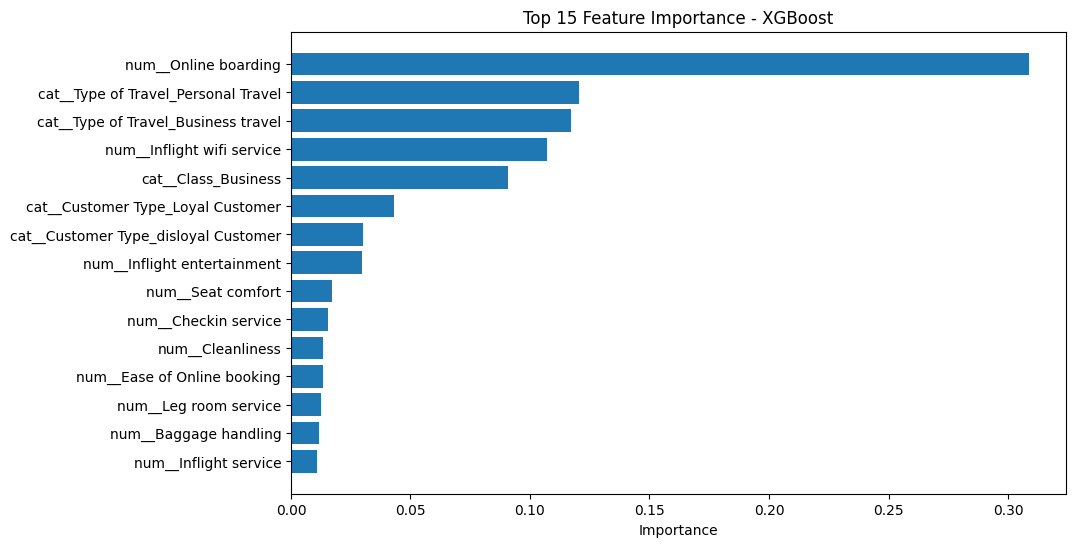

In [48]:
import matplotlib.pyplot as plt

top15 = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top15["feature"],
    top15["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - XGBoost")
plt.xlabel("Importance")

plt.show()

XGBoost가 승객 만족 여부를 분류하는 과정에서 Online boarding 정보를 중요하게 활용함

In [49]:
# 원래 변수 기준으로 합침

importance_original = []

for feature, importance in zip(feature_names, importances):

    # 숫자형 변수
    if feature.startswith("num__"):
        original_feature = feature.replace("num__", "")

    # 범주형 변수
    else:
        clean_feature = feature.replace("cat__", "")
        original_feature = clean_feature

        for col in categorical_cols:
            if clean_feature.startswith(col + "_"):
                original_feature = col
                break

    importance_original.append([
        original_feature,
        importance
    ])

In [50]:
importance_original_df = pd.DataFrame(
    importance_original,
    columns=["feature", "importance"]
)

importance_original_df = (
    importance_original_df
    .groupby("feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(importance_original_df.head(15))

                   feature  importance
0          Online boarding    0.308806
1           Type of Travel    0.237787
2    Inflight wifi service    0.107260
3                    Class    0.101135
4            Customer Type    0.073341
5   Inflight entertainment    0.029746
6             Seat comfort    0.016970
7          Checkin service    0.015582
8              Cleanliness    0.013480
9   Ease of Online booking    0.013346
10        Leg room service    0.012424
11        Baggage handling    0.011618
12        Inflight service    0.010925
13           Gate location    0.010916
14        On-board service    0.010323


승객 만족 예측에는 단순한 인구통계적 특성보다는 여행 목적·좌석 등급 등의 여행 특성과 온라인 탑승·기내 Wi-Fi 등의 서비스 평가가 상대적으로 중요한 정보로 활용됨

### Feature Importance 분석

- XGBoost Feature Importance에서 `Online boarding`이 가장 높은 중요도를 보임
- `Type of Travel`, `Inflight wifi service`, `Class`, `Customer Type` 등도 주요 변수로 나타남
- 특히 EDA에서 만족/불만족 간 차이가 크게 나타났던 `Online boarding`과 `Type of Travel`이 모델에서도 중요한 변수로 확인
- 원핫인코딩된 범주형 변수는 여러 컬럼으로 분리되므로 원래 변수 단위의 중요도도 함께 확인
- Feature Importance는 모델이 예측 과정에서 해당 변수를 얼마나 활용했는지를 나타내며 인과관계를 의미하지 않음

SHAP

c:\Users\김양일\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


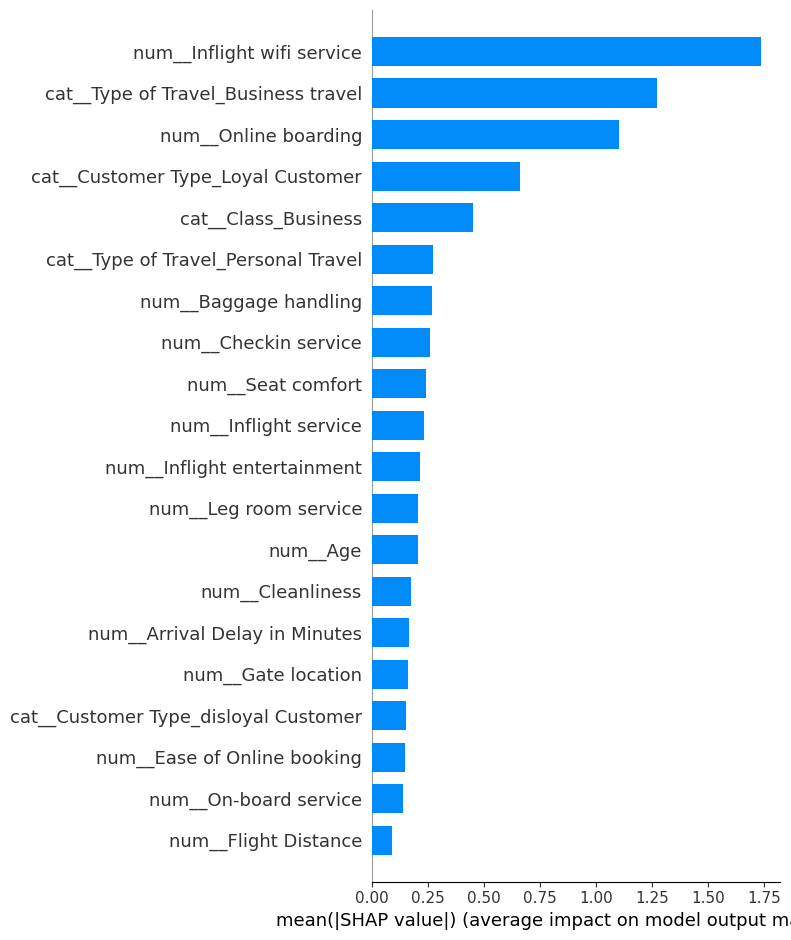

In [51]:
import shap

final_pipeline = xgb_random.best_estimator_
final_pipeline.fit(X, y)

final_preprocessor = final_pipeline.named_steps["preprocessor"]
xgb_model = final_pipeline.named_steps["classifier"]

feature_names = final_preprocessor.get_feature_names_out()

X_shap = X_test.sample(
    n=2000,
    random_state=10
)

X_shap_transformed = final_preprocessor.transform(X_shap)

if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_shap_transformed)

shap.summary_plot(
    shap_values.values,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type="bar"
)



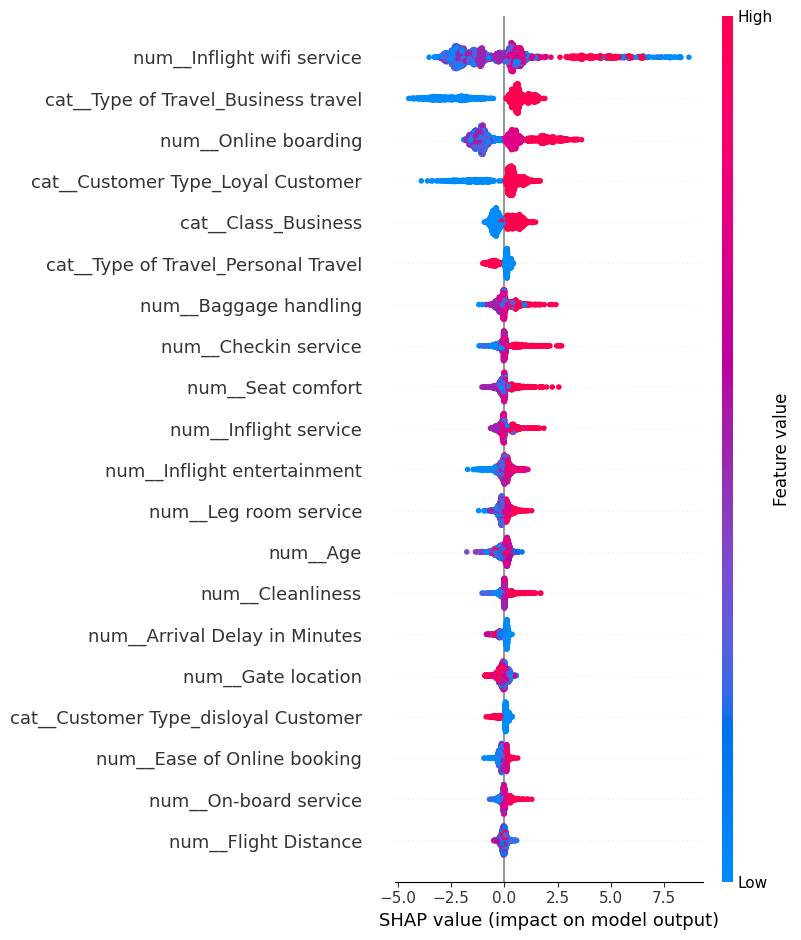

In [52]:
shap.summary_plot(
    shap_values.values,
    X_shap_transformed,
    feature_names=feature_names
)

### SHAP 결과 해석

- 기내 Wi-Fi 서비스는 전체 예측에서 가장 큰 영향을 보였으며, 높은 평가가 만족 예측 방향으로 작용하는 경향이 나타남
- Business travel은 만족 방향, Personal Travel은 불만족 방향으로 작용하는 패턴을 보임
- Online boarding 평가가 높을수록 만족 예측에 기여하는 경향이 뚜렷하게 나타남
- Loyal Customer 및 Business Class 여부 역시 만족 예측 방향에 영향을 주는 주요 특성으로 확인
- Checkin service, Seat comfort, Baggage handling 등 여러 서비스 평가에서도 높은 점수가 대체로 만족 방향으로 작용
- 반면 도착 지연시간이 증가하는 경우에는 불만족 방향으로 작용하는 경향 관찰

※ SHAP은 모델의 예측에 대한 기여도를 설명하는 것이며 실제 인과관계를 의미하지 않음